In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

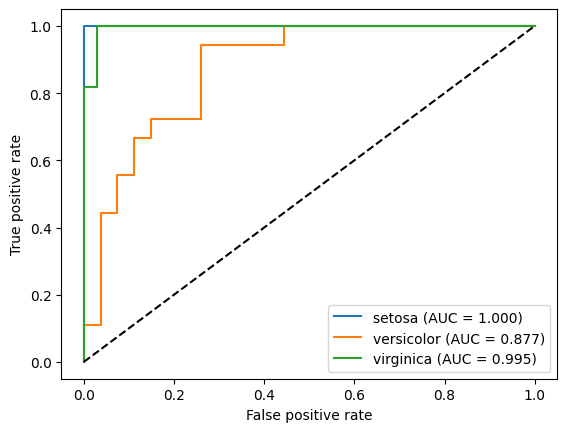

In [4]:
# Load iris dataset
iris = load_iris()

# Define variable
X = iris.data
y = iris.target

# Split data into train and test set
y_bin = label_binarize(iris.target, classes=[0, 1, 2])
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, y_bin, test_size=0.3, random_state=0)

# Call svm model
model = OneVsRestClassifier(SVC(kernel='linear', probability=True, random_state=0))
model.fit(X_train, y_train)
y_score = model.predict_proba(X_test)

# Calculate AUC & plot the ROC curve
for i, name in enumerate(iris.target_names):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
plt.show()